In [6]:

# Connecting google drive to notebook

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
# Checking Directory

import os
project_path = "/content/drive/MyDrive/Vehicle_Detection_YOLO"
print(os.path.exists(project_path))

os.listdir(project_path)

True


['Vehicle_Detection_YOLO.ipynb', 'vehicle-detection']

In [ ]:
# Installing ultralytics

!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.0 MB/s eta 0:00:00


In [8]:
# Check dataset uploaded

import os
dataset_path = "/content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection"
print(os.listdir(dataset_path))


['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'train', 'valid', 'test']


In [10]:
# checking classes
with open(dataset_path + "/data.yaml", "r") as file:
    print(file.read())


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['ambulance', 'bus', 'car', 'motorcycle', 'truck']

roboflow:
  workspace: yolo-bnlkn
  project: vehicles-ki9po
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/yolo-bnlkn/vehicles-ki9po/dataset/2


In [11]:
# confirming train valid test count dataset

print("Training images:", len(os.listdir(dataset_path + "/train/images")))
print("Training labels:", len(os.listdir(dataset_path + "/train/labels")))

print("Validation images:", len(os.listdir(dataset_path + "/valid/images")))
print("Validation labels:", len(os.listdir(dataset_path + "/valid/labels")))

print("Test images:", len(os.listdir(dataset_path + "/test/images")))
print("Test labels:", len(os.listdir(dataset_path + "/test/labels")))



Training images: 434
Training labels: 434
Validation images: 126
Validation labels: 126
Test images: 67
Test labels: 67


In [15]:
# checking GPU configuration

import torch

print("GPU available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
GPU: Tesla T4


In [17]:
# setting model

from ultralytics import YOLO
model = YOLO("yolov8n.pt")


In [18]:
# Train the model

results = model.train(
    data=dataset_path + "/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, 

In [19]:
# Validate model

metrics = model.val(
    data=dataset_path + "/data.yaml",
    split="val"
)



Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 13.4±27.7 ms, read: 23.1±31.6 MB/s, size: 56.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection/valid/labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 25.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.1s
                   all        126        223      0.741      0.576      0.643      0.478
             ambulance         15         16      0.812      0.812      0.922       0.85
                   bus         24         35      0.773      0.629      0.686      0.522
                   car     

In [20]:
# testing

test_results = model.val(
    data=dataset_path + "/data.yaml",
    split="test"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.2 ms, read: 0.2±0.0 MB/s, size: 57.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection/test/labels... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67 1.2it/s 54.9s
val: New cache created: /content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.2s
                   all         67        113      0.687      0.512      0.575        0.4
             ambulance         15         25       0.93      0.532      0.705      0.537
                   bus   

In [21]:
# giving one image

import os

test_image = os.path.join(
    dataset_path,
    "test/images",
    os.listdir(os.path.join(dataset_path, "test/images"))[0]
)

results = model.predict(
    source=test_image,
    conf=0.25
)



image 1/1 /content/drive/MyDrive/Vehicle_Detection_YOLO/vehicle-detection/test/images/00e2d9121adc0c20_jpg.rf.df8f8074d3a3573ec5e2a7a9867b1e66.jpg: 640x640 1 ambulance, 53.7ms
Speed: 2.5ms preprocess, 53.7ms inference, 22.6ms postprocess per image at shape (1, 3, 640, 640)


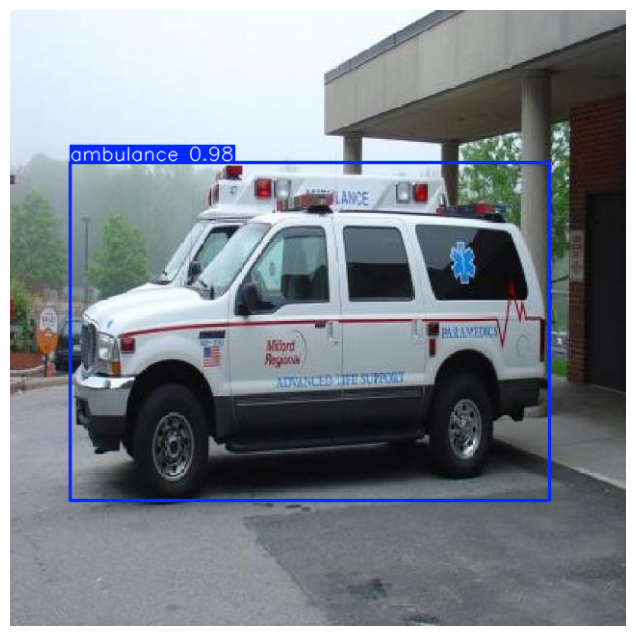

In [22]:
# display prediction

import matplotlib.pyplot as plt

result = results[0]

plt.figure(figsize=(10, 8))
plt.imshow(result.plot()[..., ::-1])
plt.axis("off")
plt.show()



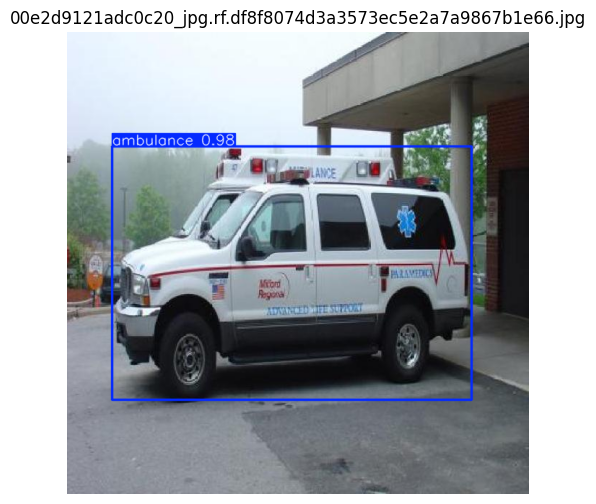

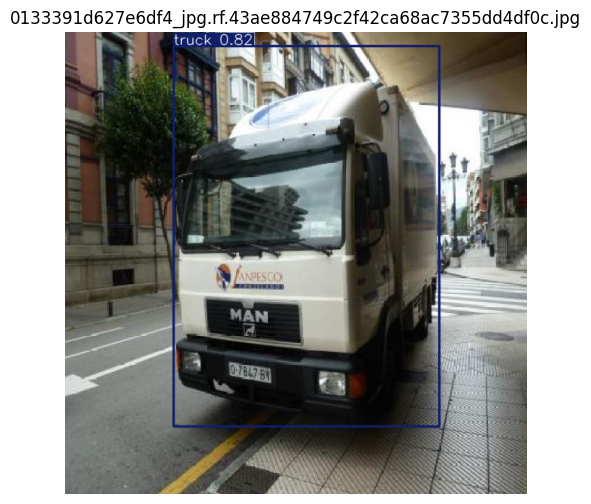

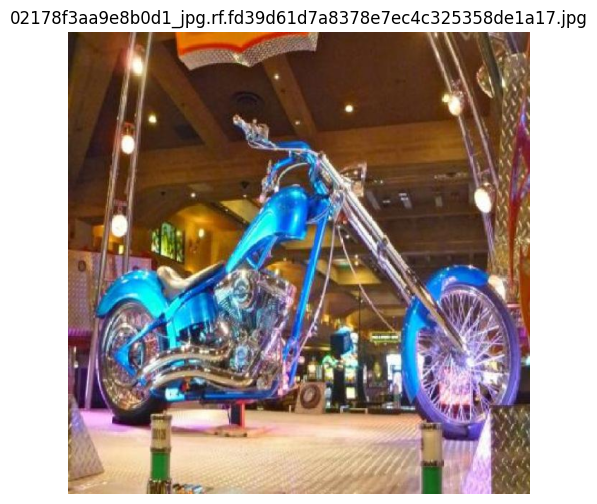

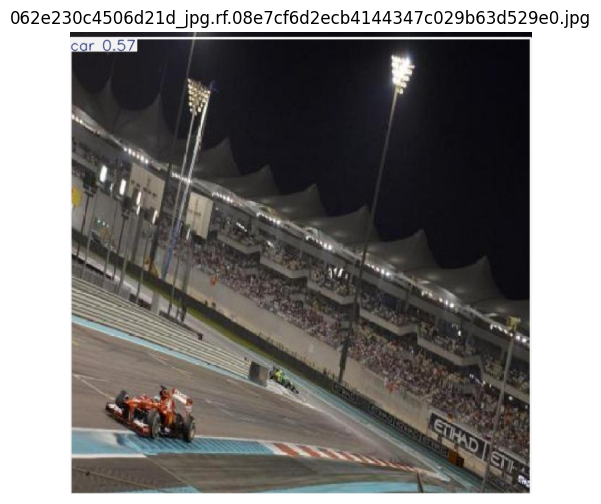

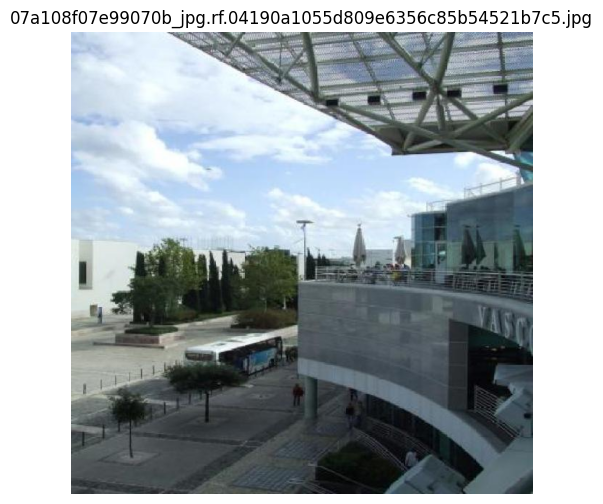

In [23]:
# multiple image detection

import os

test_dir = os.path.join(dataset_path, "test/images")
test_images = os.listdir(test_dir)[:5]

for image_name in test_images:
    image_path = os.path.join(test_dir, image_name)

    results = model.predict(
        source=image_path,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    plt.figure(figsize=(8, 6))
    plt.imshow(result.plot()[..., ::-1])
    plt.title(image_name)
    plt.axis("off")
    plt.show()

